# 🌊 Underwater Drone / Marine Animal Discrimination System
**Project P095 | Rupanbittu | Roll No: 142301019**  
**Mentor: Dr. M. Sabarimalai Manikandan**

---

## What this notebook does — step by step

```
INPUT IMAGE
     ↓
  STEP 1 : Image Enhancement  (Gray World + CLAHE + Sharpen)
     ↓
  STEP 2 : Fish Model (EfficientNet-B0)  → Is FISH / MARINE ANIMAL present?
  STEP 3 : Drone Model (EfficientNet-B0) → Is UNDERWATER DRONE present?  [always runs]
     ↓
  STEP 4 : Decision Logic
     → Fish only?  Drone only?  Both?  Neither?
     → If both: Fish Grad-CAM first, then Drone Grad-CAM
     ↓
  STEP 5 : Grad-CAM  → WHERE in the image is the object?
     ↓
  STEP 6 : Thresholding  → Convert heatmap to binary mask
     ↓
  STEP 7 : Morphology   → Clean the mask (close holes, remove noise)
     ↓
  STEP 8 : Contour + Bounding Box  → Draw box and label on image
     ↓
  FINAL OUTPUT : Original | Enhanced | GradCAM | Final Detection
```

### Why EfficientNet-B0?
- Only **5.3M parameters** → runs on CPU / Raspberry Pi
- ImageNet pretrained → strong base features, fine-tuned for underwater
- Best accuracy-vs-energy trade-off (key project objective)

### Dataset layout required
```
dataset/
  marine_animal/     ← all fish / marine images (flat folder, ~3600 images)
  underwater_drone/  ← all drone / ROV images   (flat folder, ~54 images)
test_images/         ← put your inference images here
```

> **Key design principle:**
> - Fish model trains **only** on fish images (train/valid/test split from `marine_animal/`).
>   Its negatives are a held-out subset of its **own** folder (empty/no-fish images if available,
>   or a random held-out portion auto-labelled as not-present).
> - Drone model trains **only** on drone images (split from `underwater_drone/`).
>   No fish images are ever used as drone negatives.


## Cell 1 — Install libraries (run once)

In [2]:
# Run this cell once if libraries are not installed
# !pip install torch torchvision opencv-python matplotlib scikit-learn tqdm pillow

import os, random, warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import models, transforms
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

# ── Device: use GPU if available, else CPU ────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✔ Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  Running on CPU — training will be slower but fully functional")


✔ Device: cuda
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## Cell 2 — Project settings (edit paths here if needed)


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PROJECT PATHS  ← edit DATASET_DIR to match your machine
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET_DIR  = Path(r"D:\FINAL\dataset")         # ← absolute path to your dataset
MARINE_DIR   = DATASET_DIR / "marine_animal"
DRONE_DIR    = DATASET_DIR / "underwater_drone"
MODELS_DIR   = Path("models")
OUTPUT_DIR   = Path("output")
TEST_DIR     = Path("test_images")

for d in [MODELS_DIR, OUTPUT_DIR, TEST_DIR]:
    d.mkdir(exist_ok=True)

# ── Subfolder names (same layout for both marine and drone) ───────────────────
# Both marine_animal/ and underwater_drone/ contain:
#   valid/  → images where the target IS present  (label = 1)
#   empty/  → background images, target absent    (label = 0)
PRESENT_SUBDIR     = "valid"    # subfolder name for positive images
NOTPRESENT_SUBDIR  = "empty"    # subfolder name for negative/background images

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# HYPERPARAMETERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
IMAGE_SIZE    = 224
BATCH_SIZE    = 16
EPOCHS        = 15
LR            = 1e-4
THRESHOLD     = 0.50
# Separate demo thresholds: fish is kept stricter to reduce drone→fish false positives
FISH_THRESHOLD  = 0.70
DRONE_THRESHOLD = 0.55
CONF_MARGIN     = 0.10   # if both are present, stronger class wins only if ahead by this margin
DEMO_MAX_SIDE   = 960    # resize test/demo image before annotation; keeps aspect ratio
FREEZE_EPOCHS = 5
VAL_RATIO     = 0.15
TEST_RATIO    = 0.10

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("✔ Settings loaded")
print(f"  Dataset root         : {DATASET_DIR}")
print(f"  Marine animal folder : {MARINE_DIR}")
print(f"  Drone folder         : {DRONE_DIR}")
print(f"  Present subfolder    : {PRESENT_SUBDIR}/")
print(f"  Not-present subfolder: {NOTPRESENT_SUBDIR}/")
print(f"  Epochs               : {EPOCHS}")
print(f"  Batch size           : {BATCH_SIZE}")
print(f"  Detection threshold  : {THRESHOLD}")
print(f"  Fish / Drone thresholds: {FISH_THRESHOLD} / {DRONE_THRESHOLD}")
print(f"  Demo max image side   : {DEMO_MAX_SIDE}px")


✔ Settings loaded
  Dataset root         : D:\FINAL\dataset
  Marine animal folder : D:\FINAL\dataset\marine_animal
  Drone folder         : D:\FINAL\dataset\underwater_drone
  Present subfolder    : valid/
  Not-present subfolder: empty/
  Epochs               : 15
  Batch size           : 16
  Detection threshold  : 0.5


## Cell 3 — Check your dataset

Detects whether `marine_animal/` contains `present/` and `not_present/` subfolders  
and whether a `background/` folder exists for drone negatives.


In [4]:
def list_images(folder):
    """Return all image file paths inside a folder (recursive)."""
    folder = Path(folder)
    if not folder.exists():
        return []
    return [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS]


# ── Marine animal subfolders ──────────────────────────────────────────────────
marine_present_dir     = MARINE_DIR  / PRESENT_SUBDIR
marine_notpresent_dir  = MARINE_DIR  / NOTPRESENT_SUBDIR
MARINE_HAS_SUBFOLDERS  = marine_present_dir.exists() and marine_notpresent_dir.exists()
marine_present_imgs    = list_images(marine_present_dir)    if MARINE_HAS_SUBFOLDERS else []
marine_notpresent_imgs = list_images(marine_notpresent_dir) if MARINE_HAS_SUBFOLDERS else []

# ── Drone subfolders (same layout: valid/ + empty/) ───────────────────────────
drone_present_dir     = DRONE_DIR / PRESENT_SUBDIR
drone_notpresent_dir  = DRONE_DIR / NOTPRESENT_SUBDIR
DRONE_HAS_SUBFOLDERS  = drone_present_dir.exists() and drone_notpresent_dir.exists()
drone_present_imgs    = list_images(drone_present_dir)    if DRONE_HAS_SUBFOLDERS else []
drone_notpresent_imgs = list_images(drone_notpresent_dir) if DRONE_HAS_SUBFOLDERS else []

print("━" * 55)
print("DATASET SUMMARY")
print("━" * 55)

# Marine
if MARINE_HAS_SUBFOLDERS:
    print(f"  marine_animal/{PRESENT_SUBDIR}/     : {len(marine_present_imgs):>5d} images  ✔")
    print(f"  marine_animal/{NOTPRESENT_SUBDIR}/      : {len(marine_notpresent_imgs):>5d} images  ✔")
else:
    print(f"  marine_animal/  : {len(list_images(MARINE_DIR)):>5d} images")
    print(f"  ⚠  No {PRESENT_SUBDIR}/ and {NOTPRESENT_SUBDIR}/ subfolders found in marine_animal/")

# Drone
if DRONE_HAS_SUBFOLDERS:
    print(f"  underwater_drone/{PRESENT_SUBDIR}/   : {len(drone_present_imgs):>5d} images  ✔")
    print(f"  underwater_drone/{NOTPRESENT_SUBDIR}/    : {len(drone_notpresent_imgs):>5d} images  ✔")
else:
    all_drone = list_images(DRONE_DIR)
    print(f"  underwater_drone/ : {len(all_drone):>5d} images")
    print(f"  ⚠  No {PRESENT_SUBDIR}/ and {NOTPRESENT_SUBDIR}/ subfolders found in underwater_drone/")

print("━" * 55)

# Warnings
if DRONE_HAS_SUBFOLDERS and len(drone_present_imgs) < 100:
    print(f"⚠  Drone dataset is small ({len(drone_present_imgs)} positive images).")
    print("   Heavy augmentation + oversampling will be applied automatically.")

ok = (MARINE_HAS_SUBFOLDERS or len(list_images(MARINE_DIR)) > 0) and      (DRONE_HAS_SUBFOLDERS  or len(list_images(DRONE_DIR))  > 0)
if ok:
    print("✔ Dataset looks good. Ready to train.")
else:
    print("❌ ERROR: Missing dataset folders. Check paths in Cell 2.")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  marine_animal/valid/     :  2624 images  ✔
  marine_animal/empty/      :   141 images  ✔
  underwater_drone/valid/   :   103 images  ✔
  underwater_drone/empty/    :   108 images  ✔
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✔ Dataset looks good. Ready to train.


## Cell 4 — Image Enhancement pipeline

Underwater images suffer from blue-green colour cast, low contrast, and blur.  
We apply 3 steps before feeding to the model:

1. **Gray World White Balance** — removes the blue/green underwater colour cast
2. **CLAHE** — improves local contrast without over-brightening
3. **Mild Unsharp Mask** — restores edge sharpness lost due to water scattering

In [5]:
def gray_world_white_balance(img_bgr):
    """
    Gray World White Balance:
    Assumes the average colour of a scene is neutral gray.
    Rescales each channel so all means become equal.
    → Removes the strong blue/green underwater tint.
    """
    img   = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mean_b, mean_g, mean_r = b.mean(), g.mean(), r.mean()
    mean_gray = (mean_b + mean_g + mean_r) / 3.0
    b *= mean_gray / (mean_b + 1e-6)
    g *= mean_gray / (mean_g + 1e-6)
    r *= mean_gray / (mean_r + 1e-6)
    return np.clip(cv2.merge([b, g, r]), 0, 255).astype(np.uint8)


def apply_clahe(img_bgr):
    """
    CLAHE (Contrast Limited Adaptive Histogram Equalization):
    Applied on the L channel of LAB color space.
    → Improves local contrast without washing out the image.
    """
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)


def mild_sharpen(img_bgr):
    """
    Unsharp masking:
    Subtracts a blurred version to emphasise edges.
    → Restores sharpness lost due to water scattering / haze.
    """
    blur  = cv2.GaussianBlur(img_bgr, (0, 0), sigmaX=1.0)
    sharp = cv2.addWeighted(img_bgr, 1.4, blur, -0.4, 0)
    return np.clip(sharp, 0, 255).astype(np.uint8)


def enhance_underwater_image(img_bgr):
    """
    Full enhancement pipeline applied before model inference:
      1. Gray World White Balance  → fix colour cast
      2. CLAHE                     → improve contrast
      3. Mild Unsharp Mask         → restore sharpness
    """
    img = gray_world_white_balance(img_bgr)
    img = apply_clahe(img)
    img = mild_sharpen(img)
    return img


print("✔ Enhancement functions defined")

✔ Enhancement functions defined


## Cell 5 — Test enhancement on a sample image

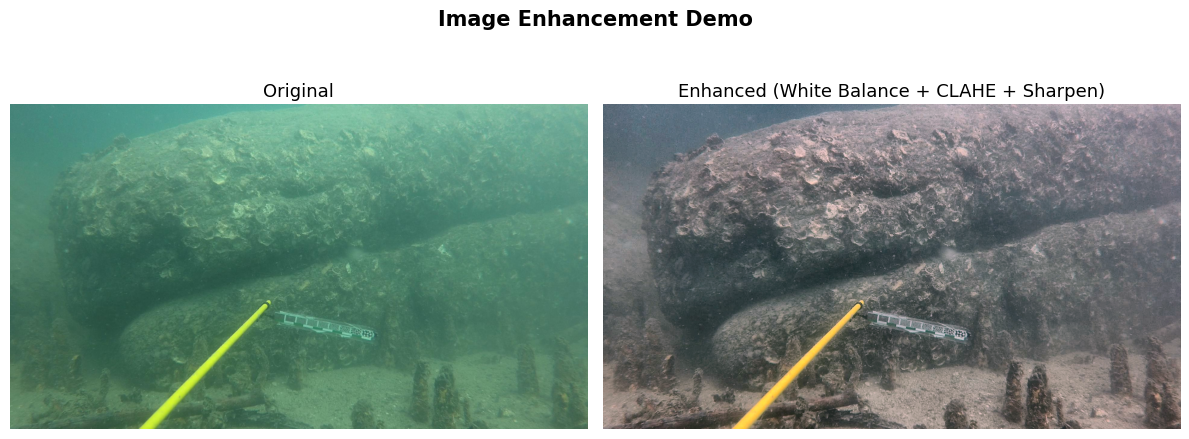

✔ Saved: output/enhancement_demo.jpg


In [6]:
# Pick any image from your marine_animal or drone folder to test enhancement
sample_paths = list_images(MARINE_DIR) + list_images(DRONE_DIR)

if len(sample_paths) > 0:
    sample_path = sample_paths[98]           # use the first image found
    img_bgr     = cv2.imread(str(sample_path))
    enhanced    = enhance_underwater_image(img_bgr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(img_bgr,  cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original", fontsize=13)
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Enhanced (White Balance + CLAHE + Sharpen)", fontsize=13)
    axes[1].axis("off")
    plt.suptitle("Image Enhancement Demo", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / "enhancement_demo.jpg"), dpi=120, bbox_inches="tight")
    plt.show()
    print(f"✔ Saved: output/enhancement_demo.jpg")
else:
    print("No images found. Add images to dataset/ first.")

## Cell 6 — Dataset class + Transforms

Both models use **identical subfolder layout**: `valid/` (present) and `empty/` (not present).
A single shared `_make_subfolder_splits()` function handles both — oversampling kicks in
automatically when the positive set has fewer than 200 images (drone model).


In [7]:

# ── Standard transforms ─────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

drone_train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.4),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.08),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),   # model tensor resize: every test image becomes 224×224 for EfficientNet
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def _split_list(lst, val_ratio, test_ratio, rng):
    """Shuffle and split a list into (train, val, test) by ratio."""
    lst = list(lst)
    rng.shuffle(lst)
    n      = len(lst)
    n_test = max(int(n * test_ratio), 1)
    n_val  = max(int(n * val_ratio),  1)
    test   = lst[:n_test]
    val    = lst[n_test:n_test + n_val]
    train  = lst[n_test + n_val:]
    return train, val, test


def _make_subfolder_splits(model_name, pos_imgs, neg_imgs,
                            val_ratio=VAL_RATIO, test_ratio=TEST_RATIO,
                            oversample_factor=8, seed=42):
    """
    Build train/valid/test splits for one binary model.

    pos_imgs: target-present images → label = 1
    neg_imgs: true negatives + hard negatives → label = 0

    Important update:
      fish model negatives include drone/ROV images.
      drone model negatives include fish/marine images.
    This teaches the model that "drone is NOT fish" and "fish is NOT drone".
    """
    rng = random.Random(seed)

    p_train, p_val, p_test = _split_list(pos_imgs, val_ratio, test_ratio, rng)
    n_train, n_val, n_test = _split_list(neg_imgs, val_ratio, test_ratio, rng)

    # Oversample positives in training split when dataset is small
    if len(p_train) < 200:
        p_train = p_train * oversample_factor
        rng.shuffle(p_train)
        oversample_note = f"  (oversampled positives {oversample_factor}×)"
    else:
        oversample_note = ""

    def make_pairs(pos, neg):
        pairs = [(p, 1) for p in pos] + [(p, 0) for p in neg]
        rng.shuffle(pairs)
        return pairs

    train_samples = make_pairs(p_train, n_train)
    val_samples   = make_pairs(p_val,   n_val)
    test_samples  = make_pairs(p_test,  n_test)

    print(f"  [{model_name}: positive vs hard-negative]{oversample_note}")
    for split_name, split in [("train", train_samples), ("valid", val_samples), ("test", test_samples)]:
        n_pos = sum(1 for _, l in split if l == 1)
        n_neg = sum(1 for _, l in split if l == 0)
        print(f"    {split_name:5s} : {n_pos:4d} present  +  {n_neg:4d} not_present  =  {len(split):4d} total")

    return train_samples, val_samples, test_samples


def make_marine_splits(val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, seed=42):
    """
    Fish model:
      positive = marine_animal/valid/
      negative = marine_animal/empty/ + underwater_drone/valid/ + underwater_drone/empty/
    """
    if not MARINE_HAS_SUBFOLDERS:
        raise RuntimeError(
            f"marine_animal/ must contain {PRESENT_SUBDIR}/ and {NOTPRESENT_SUBDIR}/ subfolders.\n"
            f"Expected:\n  {marine_present_dir}\n  {marine_notpresent_dir}"
        )

    fish_pos = marine_present_imgs
    fish_neg = marine_notpresent_imgs + drone_present_imgs + drone_notpresent_imgs

    return _make_subfolder_splits(
        "fish", fish_pos, fish_neg,
        val_ratio=val_ratio, test_ratio=test_ratio, seed=seed
    )


def make_drone_splits(val_ratio=VAL_RATIO, test_ratio=TEST_RATIO,
                      oversample_factor=8, seed=42):
    """
    Drone model:
      positive = underwater_drone/valid/
      negative = underwater_drone/empty/ + marine_animal/valid/ + marine_animal/empty/
    """
    if not DRONE_HAS_SUBFOLDERS:
        raise RuntimeError(
            f"underwater_drone/ must contain {PRESENT_SUBDIR}/ and {NOTPRESENT_SUBDIR}/ subfolders.\n"
            f"Expected:\n  {drone_present_dir}\n  {drone_notpresent_dir}"
        )

    drone_pos = drone_present_imgs
    drone_neg = drone_notpresent_imgs + marine_present_imgs + marine_notpresent_imgs

    return _make_subfolder_splits(
        "drone", drone_pos, drone_neg,
        val_ratio=val_ratio, test_ratio=test_ratio,
        oversample_factor=oversample_factor, seed=seed
    )


def make_balanced_sampler(samples):
    """
    Weighted sampler so the model sees a balanced mix of present/not-present
    even when the folder counts are very different.
    """
    labels = np.array([label for _, label in samples], dtype=np.int64)
    class_counts = np.bincount(labels, minlength=2)
    class_counts = np.maximum(class_counts, 1)
    sample_weights = 1.0 / class_counts[labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


def make_ce_class_weights(samples):
    """Class weights for CrossEntropyLoss: higher weight for minority class."""
    labels = np.array([label for _, label in samples], dtype=np.int64)
    class_counts = np.bincount(labels, minlength=2)
    class_counts = np.maximum(class_counts, 1)
    weights = class_counts.sum() / (2.0 * class_counts)
    return torch.tensor(weights, dtype=torch.float32)


class PresenceDataset(Dataset):
    """Generic binary presence dataset. Takes (Path, label) tuples."""

    def __init__(self, samples, transform=None, enhance=True):
        self.samples   = samples
        self.transform = transform
        self.enhance   = enhance

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img_bgr = cv2.imread(str(path))
        if img_bgr is None:
            img_bgr = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        if self.enhance:
            img_bgr = enhance_underwater_image(img_bgr)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil     = Image.fromarray(img_rgb)
        x       = self.transform(pil) if self.transform else val_transform(pil)
        return x, torch.tensor(label, dtype=torch.long)


print("✔ Dataset helpers defined with hard-negative training")
print(f"  Fish model  → positive: marine_animal/{PRESENT_SUBDIR}/")
print(f"              → negative: marine_animal/{NOTPRESENT_SUBDIR}/ + underwater_drone/{PRESENT_SUBDIR}/ + underwater_drone/{NOTPRESENT_SUBDIR}/")
print(f"  Drone model → positive: underwater_drone/{PRESENT_SUBDIR}/")
print(f"              → negative: underwater_drone/{NOTPRESENT_SUBDIR}/ + marine_animal/{PRESENT_SUBDIR}/ + marine_animal/{NOTPRESENT_SUBDIR}/")


✔ Dataset helpers defined
  Fish model  → make_marine_splits()  reads marine_animal/valid/ + empty/
  Drone model → make_drone_splits()   reads underwater_drone/valid/ + empty/


## Cell 7 — Build EfficientNet-B0 model

**Why EfficientNet-B0?**  
- Compound scaling: width + depth + resolution scaled together  
- Only 5.3M parameters vs ResNet50's 25M  
- Achieves better accuracy per FLOP than ResNet, VGG, MobileNet  
- Ideal for embedded/drone deployment (project requirement)

In [8]:
def build_efficientnet_b0(num_classes=2, pretrained=True, freeze_backbone=True):
    """
    Build EfficientNet-B0 binary classifier.

    pretrained=True  : start from ImageNet weights (much faster convergence)
    freeze_backbone  : freeze all layers except the classifier head initially
                       → prevents destroying pretrained features in early epochs
    num_classes=2    : [not_present, present]
    """
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model   = models.efficientnet_b0(weights=weights)

    # Replace the final classifier with our binary head
    in_features = model.classifier[1].in_features   # 1280 for EfficientNet-B0
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),             # regularisation
        nn.Linear(in_features, num_classes),
    )

    if freeze_backbone:
        # Freeze all feature extraction layers
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False

    return model


def unfreeze_all(model):
    """Unfreeze all parameters for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True


# Quick check
tmp = build_efficientnet_b0(pretrained=False)
total  = sum(p.numel() for p in tmp.parameters())
frozen = sum(p.numel() for p in tmp.parameters() if not p.requires_grad)
print(f"✔ EfficientNet-B0 built")
print(f"  Total parameters     : {total/1e6:.2f}M")
print(f"  Frozen (backbone)    : {frozen/1e6:.2f}M")
print(f"  Trainable (head)     : {(total-frozen)/1000:.1f}K")
del tmp

✔ EfficientNet-B0 built
  Total parameters     : 4.01M
  Frozen (backbone)    : 4.01M
  Trainable (head)     : 2.6K


## Cell 8 — Training function

`train_model()` now automatically calls `make_marine_splits()` for the fish model  
and `make_drone_splits()` for the drone model — no more random 50/50 mislabelling.


In [9]:

def evaluate_model(model, loader):
    """Run validation pass. Returns (loss, accuracy, y_true, y_pred)."""
    model.eval()
    criterion  = nn.CrossEntropyLoss()
    total_loss = 0.0
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds  = logits.argmax(dim=1)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    n   = max(len(y_true), 1)
    acc = sum(a == b for a, b in zip(y_true, y_pred)) / n
    return total_loss / n, acc, y_true, y_pred


def train_model(model_name, image_dir,
                epochs=EPOCHS, freeze_epochs=FREEZE_EPOCHS,
                is_small_dataset=False):
    """
    Train one binary presence model.

    Updated split strategy:
      fish  → positive marine_animal/valid/
              negative marine_animal/empty/ + underwater_drone/valid/ + underwater_drone/empty/

      drone → positive underwater_drone/valid/
              negative underwater_drone/empty/ + marine_animal/valid/ + marine_animal/empty/

    This fixes the old mistake where the fish model never learned that drone/ROV = not fish.
    """
    print(f"\n{'━'*55}")
    print(f" Training: {model_name.upper()} MODEL")
    print(f" Source  : {image_dir}")
    print(f" Labels  : present=1 vs not_present=0 with hard negatives")
    print(f"{'━'*55}")

    if model_name == "fish":
        train_samples, val_samples, _ = make_marine_splits()
    else:
        train_samples, val_samples, _ = make_drone_splits(oversample_factor=8)

    aug = drone_train_transform if is_small_dataset else train_transform

    train_ds = PresenceDataset(train_samples, transform=aug,           enhance=True)
    val_ds   = PresenceDataset(val_samples,   transform=val_transform, enhance=True)

    sampler = make_balanced_sampler(train_samples)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,
                              sampler=sampler, num_workers=0,
                              pin_memory=(DEVICE.type=="cuda"))
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0)

    model = build_efficientnet_b0(pretrained=True, freeze_backbone=True).to(DEVICE)

    # Class weights reduce bias toward the larger class.
    class_weights = make_ce_class_weights(train_samples).to(DEVICE)
    print(f"  CE class weights [not_present, present]: {class_weights.detach().cpu().numpy().round(3).tolist()}")

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR * 5, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc  = 0.0
    best_path = MODELS_DIR / f"best_{model_name}.pth"
    history   = {"train_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        if epoch == freeze_epochs + 1:
            print(f"  → Epoch {epoch}: Unfreezing backbone for full fine-tuning")
            unfreeze_all(model)
            optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - freeze_epochs
            )

        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in tqdm(train_loader, desc=f"  Epoch {epoch:02d}/{epochs}", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.size(0)

        scheduler.step()
        train_loss = total_loss / max(total, 1)
        val_loss, val_acc, _, _ = evaluate_model(model, val_loader)
        history["train_loss"].append(round(train_loss, 4))
        history["val_acc"].append(round(val_acc, 4))

        bar = "█" * int(val_acc * 20) + "░" * (20 - int(val_acc * 20))
        print(f"  Epoch {epoch:02d}: loss={train_loss:.4f}  val_acc={val_acc:.4f} [{bar}]")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_path)
            print(f"    ✔ saved best model → {best_path}")

    print(f"\n✔ Best {model_name} validation accuracy: {best_acc:.4f}")
    return model, best_path, history


✔ Training functions defined


## Cell 9 — TRAIN BOTH MODELS
⚠ **Run this cell to train.** Set `TRAIN_NOW = True` below.

- **Fish model** trains only on `dataset/marine_animal/`
  — the folder is split internally into train/valid/test and labelled
  present vs not-present from fish images only. No drone data involved.
- **Drone model** trains only on `dataset/underwater_drone/`
  — same principle. No fish data involved.

Expected time on CPU: ~20–40 min for 15 epochs  
Expected time on GPU: ~3–6 min


In [10]:
TRAIN_NOW = True   # ← set True to train, False to skip (if already trained)

if TRAIN_NOW:
    # ── Model 1: Fish / Marine Animal ─────────────────────────────────────────
    # Positive: marine_animal/valid/. Negative: marine_animal/empty/ + underwater_drone/valid/ + underwater_drone/empty/.
    # This prevents drones from being learned as fish.
    fish_model, fish_path, fish_history = train_model(
        model_name       = "fish",
        image_dir        = MARINE_DIR,
        epochs           = EPOCHS,
        freeze_epochs    = FREEZE_EPOCHS,
        is_small_dataset = False,
    )

    # ── Model 2: Underwater Drone / ROV ───────────────────────────────────────
    # Positive: underwater_drone/valid/. Negative: underwater_drone/empty/ + marine_animal/valid/ + marine_animal/empty/.
    # This prevents fish/marine animals from being learned as drones.
    drone_model, drone_path, drone_history = train_model(
        model_name       = "drone",
        image_dir        = DRONE_DIR,
        epochs           = EPOCHS,
        freeze_epochs    = FREEZE_EPOCHS,
        is_small_dataset = True,    # small dataset → heavy aug + oversample
    )

    print("\n✔ Both models trained successfully!")
    print("  Next: Run Cell 10 to plot curves, then Cell 11 to load, then Cell 14 for inference.")
else:
    print("Training skipped. Set TRAIN_NOW = True to train.")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Training: FISH MODEL
 Source  : D:\FINAL\dataset\marine_animal
 Labels  : valid/ (present=1)  vs  empty/ (not_present=0)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [marine — valid/ vs empty/]
    train : 1969 present  +   106 not_present  =  2075 total
    valid :  393 present  +    21 not_present  =   414 total
    test  :  262 present  +    14 not_present  =   276 total


  Epoch 01 | loss=0.2115 | val_acc=94.2% [██████████████████░░]


  Epoch 02 | loss=0.1499 | val_acc=93.7% [██████████████████░░]


  Epoch 03 | loss=0.1302 | val_acc=93.5% [██████████████████░░]


  Epoch 04 | loss=0.1289 | val_acc=94.0% [██████████████████░░]


...

  Epoch 11 | loss=0.0095 | val_acc=100.0% [████████████████████]


  Epoch 12 | loss=0.0027 | val_acc=100.0% [████████████████████]


  Epoch 13 | loss=0.0037 | val_acc=100.0% [████████████████████]


  Epoch 14 | loss=0.0097 | val_acc=100.0% [████████████████████]


  Epoch 15 | loss=0.0026 | val_acc=100.0% [████████████████████]

  ✔ Best val accuracy: 100.0%  →  saved: models\best_drone.pth

✔ Both models trained successfully!
  Next: Run Cell 10 to plot curves, then Cell 11 to load, then Cell 14 for inference.


## Cell 10 — Plot training curves

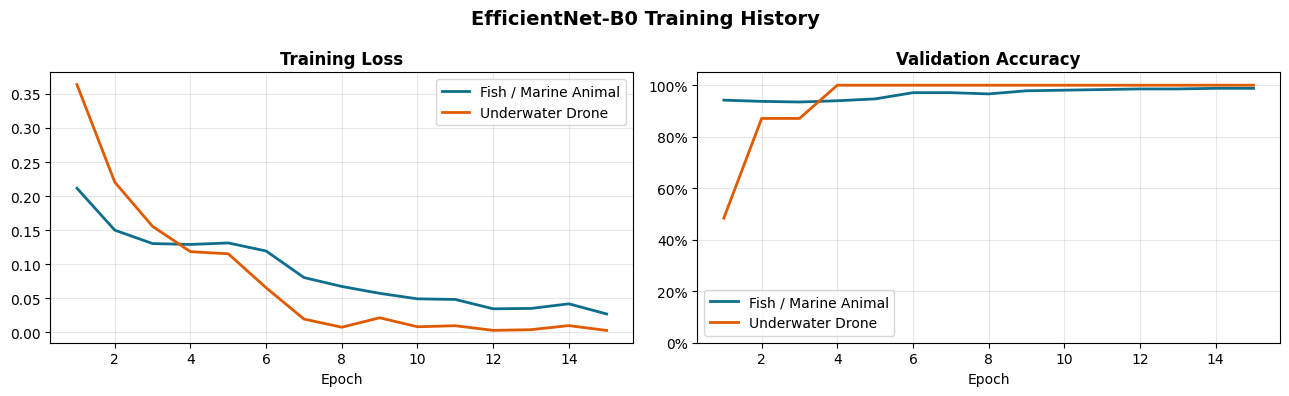

✔ Saved: output/training_curves.jpg


In [17]:
def plot_training_history(histories, names):
    """Plot training loss and validation accuracy for both models."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    colors = ["#0E6E8C", "#E05A00"]

    for i, (hist, name) in enumerate(zip(histories, names)):
        epochs_range = range(1, len(hist["train_loss"]) + 1)
        axes[0].plot(epochs_range, hist["train_loss"], color=colors[i], linewidth=2, label=name)
        axes[1].plot(epochs_range, hist["val_acc"],   color=colors[i], linewidth=2, label=name)

    axes[0].set_title("Training Loss",       fontsize=12, fontweight="bold")
    axes[1].set_title("Validation Accuracy", fontsize=12, fontweight="bold")
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1.05)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    plt.suptitle("EfficientNet-B0 Training History", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / "training_curves.jpg"), dpi=120, bbox_inches="tight")
    plt.show()
    print("✔ Saved: output/training_curves.jpg")


try:
    plot_training_history([fish_history, drone_history], ["Fish / Marine Animal", "Underwater Drone"])
except NameError:
    print("Train models first (Cell 9) to see curves.")


## Cell 11 — Load trained models

In [18]:
def load_model(path):
    """Load a saved EfficientNet-B0 checkpoint."""
    ckpt  = torch.load(path, map_location=DEVICE)
    model = build_efficientnet_b0(num_classes=2, pretrained=False,
                                   freeze_backbone=False).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt


fish_model_path  = MODELS_DIR / "best_fish.pth"
drone_model_path = MODELS_DIR / "best_drone.pth"

fish_model = drone_model = None

if fish_model_path.exists():
    fish_model, fish_ckpt = load_model(fish_model_path)
    print(f"✔ Fish model loaded   |  val_acc={fish_ckpt['val_acc']:.1%}")
else:
    print(f"❌ Fish model not found: {fish_model_path}")
    print("   → Run Cell 9 to train first.")

if drone_model_path.exists():
    drone_model, drone_ckpt = load_model(drone_model_path)
    print(f"✔ Drone model loaded  |  val_acc={drone_ckpt['val_acc']:.1%}")
else:
    print(f"❌ Drone model not found: {drone_model_path}")
    print("   → Run Cell 9 to train first.")


✔ Fish model loaded   |  val_acc=98.8%
✔ Drone model loaded  |  val_acc=100.0%


## Cell 12 — Grad-CAM + Mask + Box pipeline

```
Grad-CAM heatmap
      ↓
  Threshold (0.35) → Binary mask  [black/white]
      ↓
  Morphological Close  → fill holes
  Morphological Open   → remove noise
      ↓
  findContours → extract blobs
      ↓
  boundingRect → draw box + label
```

In [19]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Hooks into the last convolutional layer of EfficientNet-B0.
    Backpropagates class score → computes spatial importance map.
    → Tells us WHERE in the image the model found the object.
    """

    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        # Register hooks to capture forward activations and backward gradients
        self._fwd = target_layer.register_forward_hook(self._save_activation)
        self._bwd = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def remove(self):
        self._fwd.remove()
        self._bwd.remove()

    def __call__(self, tensor, class_idx=1):
        """
        Generate CAM for class_idx=1 (present).
        Returns normalized heatmap [0,1] as numpy array.
        """
        self.model.eval()
        output = self.model(tensor)
        self.model.zero_grad()
        output[:, class_idx].sum().backward(retain_graph=True)

        # Global average pool gradients → channel weights
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam     = (weights * self.activations).sum(dim=1).squeeze()  # [H, W]
        cam     = F.relu(cam)                  # keep only positive activations
        cam     = cam.detach().cpu().numpy()

        # Normalize to [0, 1]
        cam -= cam.min()
        if cam.max() > 1e-6:
            cam /= cam.max()
        return cam.astype(np.float32)


def cam_to_pseudo_mask(cam, target_wh, threshold=0.35):
    """
    Convert Grad-CAM heatmap to a clean binary mask.

    Steps:
      1. Resize CAM to original image size
      2. Threshold: pixels > threshold*255 → white (object region)
      3. Morphological CLOSE → fills internal holes
      4. Morphological OPEN  → removes small noise specks
    """
    cam_r  = cv2.resize(cam, target_wh, interpolation=cv2.INTER_LINEAR)
    cam_u8 = (cam_r * 255).astype(np.uint8)

    # Threshold
    _, mask = cv2.threshold(cam_u8, int(threshold * 255), 255, cv2.THRESH_BINARY)

    # Morphological operations to clean the mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    return mask


def extract_boxes_from_mask(mask, min_area=100):
    """
    Find contours in the binary mask and convert to bounding boxes.
    Filters out tiny blobs smaller than min_area pixels.
    Returns list of (x1, y1, x2, y2).
    """
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    boxes = []
    for cnt in contours:
        if cv2.contourArea(cnt) >= min_area:
            x, y, w, h = cv2.boundingRect(cnt)
            boxes.append((x, y, x + w, y + h))
    return boxes


def preprocess_image(img_bgr, enhance=True):
    """Enhance → convert to RGB → apply val_transform → return tensor."""
    if enhance:
        img_bgr = enhance_underwater_image(img_bgr)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil     = Image.fromarray(img_rgb)
    tensor  = val_transform(pil).unsqueeze(0).to(DEVICE)
    return tensor, img_bgr


def get_confidence(model, tensor):
    """Return confidence score for class 1 (present)."""
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)
    return float(probs[0, 1].item())


print("✔ Grad-CAM and mask pipeline defined")

✔ Grad-CAM and mask pipeline defined


## Cell 13 — Full inference function

**Updated inference logic:**

```
INPUT IMAGE
     ↓
Resize demo image for stable display/annotation
     ↓
Enhance image
     ↓
Fish Model  → fish_conf
Drone Model → drone_conf
     ↓
Separate thresholds:
  fish_present  = fish_conf  ≥ FISH_THRESHOLD
  drone_present = drone_conf ≥ DRONE_THRESHOLD
     ↓
Conflict rule:
  if both are present and one confidence is higher by CONF_MARGIN,
  keep only the stronger class.
     ↓
Grad-CAM → mask → morphology → bounding box → final annotation
```

This avoids the old problem where a drone image could be annotated as both **FISH** and **DRONE**.


In [20]:

CATEGORY_CONFIG = {
    "fish":  {"label": "FISH / MARINE", "color_bgr": (0, 200, 0),  "color_mpl": "lime"},
    "drone": {"label": "DRONE / ROV",   "color_bgr": (0, 0, 220),  "color_mpl": "red"},
}


def resize_keep_aspect(img_bgr, max_side=DEMO_MAX_SIDE):
    """
    Resize test/demo image before enhancement and annotation.
    Keeps aspect ratio, so boxes and masks still align correctly.
    """
    h, w = img_bgr.shape[:2]
    scale = min(max_side / max(h, w), 1.0)  # do not enlarge small images
    if scale < 1.0:
        new_w = int(w * scale)
        new_h = int(h * scale)
        img_bgr = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return img_bgr


def draw_box_label(img, boxes, label, color_bgr, conf):
    """Draw bounding box + label + confidence on image."""
    out = img.copy()
    full_label = f"{label}  {conf*100:.1f}%"
    for (x1, y1, x2, y2) in boxes:
        cv2.rectangle(out, (x1, y1), (x2, y2), color_bgr, 3)
        (tw, th), base = cv2.getTextSize(full_label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        ty = max(y1 - 8, th + 10)
        cv2.rectangle(out, (x1, ty - th - 8), (x1 + tw + 8, ty + base + 2), color_bgr, -1)
        cv2.putText(out, full_label, (x1 + 4, ty),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    return out


def draw_status_panel(img, results, thresholds):
    """Draw semi-transparent status panel in top-left corner."""
    out     = img.copy()
    overlay = img.copy()
    panel_h = 35 + len(results) * 34
    cv2.rectangle(overlay, (0, 0), (430, panel_h), (15, 15, 15), -1)
    out = cv2.addWeighted(overlay, 0.65, out, 0.35, 0)
    for i, (cat, conf) in enumerate(results.items()):
        thr = thresholds[cat]
        present = conf >= thr
        status  = "PRESENT" if present else "NOT PRESENT"
        color   = CATEGORY_CONFIG[cat]["color_bgr"] if present else (160, 160, 160)
        text    = f"{CATEGORY_CONFIG[cat]['label']}: {status} ({conf*100:.1f}%, thr={thr:.2f})"
        cv2.putText(out, text, (10, 28 + i * 34),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.58, color, 2, cv2.LINE_AA)
    return out


def apply_conflict_rule(fish_conf, drone_conf,
                        fish_threshold=FISH_THRESHOLD,
                        drone_threshold=DRONE_THRESHOLD,
                        margin=CONF_MARGIN):
    """
    Decide final labels from two independent classifiers.

    If both are above threshold, keep only the stronger class when the difference
    is clear. If the scores are close, keep both because the image may contain both.
    """
    fish_present  = fish_conf  >= fish_threshold
    drone_present = drone_conf >= drone_threshold
    reason = ""

    if fish_present and drone_present:
        if drone_conf >= fish_conf + margin:
            fish_present = False
            reason = "Both above threshold, but drone confidence is clearly stronger → suppress fish."
        elif fish_conf >= drone_conf + margin:
            drone_present = False
            reason = "Both above threshold, but fish confidence is clearly stronger → suppress drone."
        else:
            reason = "Both above threshold and close → keep both."
    elif fish_present:
        reason = "Only fish crossed threshold."
    elif drone_present:
        reason = "Only drone crossed threshold."
    else:
        reason = "Neither crossed threshold."

    return fish_present, drone_present, reason


def run_gradcam_and_draw(model, tensor, enhanced, label, color_bgr, conf, h, w):
    """
    Run Grad-CAM for one model, produce heatmap and bounding boxes.
    Returns (gradcam_overlay, binary_mask, boxes).
    """
    gradcam  = GradCAM(model, model.features[-1])
    cam      = gradcam(tensor, class_idx=1)
    gradcam.remove()

    cam_r   = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap((cam_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(enhanced, 0.55, heatmap, 0.45, 0)

    mask  = cam_to_pseudo_mask(cam, (w, h), threshold=0.35)
    boxes = extract_boxes_from_mask(mask, min_area=100)
    if not boxes:
        boxes = extract_boxes_from_mask(mask, min_area=20)

    return overlay, mask, boxes


def run_inference(image_path,
                  fish_threshold=FISH_THRESHOLD,
                  drone_threshold=DRONE_THRESHOLD,
                  enhance=True,
                  resize_input=True,
                  max_side=DEMO_MAX_SIDE,
                  save=True):
    """
    Final demo inference pipeline:

    1. Load image
    2. Resize test/demo input for stable annotation display
    3. Enhance image
    4. Fish model  → fish_conf
    5. Drone model → drone_conf
    6. Apply separate thresholds + conflict rule
    7. Grad-CAM → mask → morphology → bounding boxes for final accepted class/classes
    8. Save original/resized, enhanced, Grad-CAM, mask, and final annotated image
    """
    if fish_model is None or drone_model is None:
        print("❌ Models not loaded. Run Cell 11 first.")
        return

    image_path = Path(image_path)
    original   = cv2.imread(str(image_path))
    if original is None:
        print(f"❌ Cannot read image: {image_path}")
        return

    # Resize test input before enhancement and annotation.
    # Note: the model tensor is still resized to IMAGE_SIZE×IMAGE_SIZE inside val_transform.
    original_full = original.copy()
    if resize_input:
        original = resize_keep_aspect(original, max_side=max_side)

    h, w = original.shape[:2]

    # ── STEP 1: Enhancement + tensor preprocessing ────────────────────────────
    tensor, enhanced = preprocess_image(original, enhance=enhance)

    # ── STEP 2: Independent confidence scores ─────────────────────────────────
    fish_conf  = get_confidence(fish_model,  tensor)
    drone_conf = get_confidence(drone_model, tensor)

    # ── STEP 3: Separate thresholds + conflict rule ───────────────────────────
    fish_present, drone_present, decision_reason = apply_conflict_rule(
        fish_conf, drone_conf,
        fish_threshold=fish_threshold,
        drone_threshold=drone_threshold,
        margin=CONF_MARGIN
    )

    results    = {"fish": fish_conf, "drone": drone_conf}
    thresholds = {"fish": fish_threshold, "drone": drone_threshold}

    print("━" * 55)
    print(f" INFERENCE: {image_path.name}")
    print("━" * 55)
    print(f"  {'FISH / MARINE':20s} : {'✔ PRESENT' if fish_present else '✗ NOT PRESENT'}  ({fish_conf*100:.2f}%, thr={fish_threshold:.2f})")
    print(f"  {'DRONE / ROV':20s} : {'✔ PRESENT' if drone_present else '✗ NOT PRESENT'}  ({drone_conf*100:.2f}%, thr={drone_threshold:.2f})")
    print(f"  Decision: {decision_reason}")
    print("━" * 55)

    # ── STEP 4: Grad-CAM for final accepted classes ───────────────────────────
    final_img      = enhanced.copy()
    gradcam_images = {}
    mask_images    = {}
    final_detections = []

    ordered = []
    if fish_present:
        ordered.append(("fish",  fish_model,  fish_conf))
    if drone_present:
        ordered.append(("drone", drone_model, drone_conf))

    for cat, model, conf in ordered:
        overlay, mask, boxes = run_gradcam_and_draw(
            model, tensor, enhanced,
            CATEGORY_CONFIG[cat]["label"],
            CATEGORY_CONFIG[cat]["color_bgr"],
            conf, h, w
        )
        gradcam_images[cat] = overlay
        mask_images[cat]    = mask

        # If no contour is found, don't draw a fake box.
        if len(boxes) > 0:
            final_img = draw_box_label(
                final_img, boxes,
                CATEGORY_CONFIG[cat]["label"],
                CATEGORY_CONFIG[cat]["color_bgr"],
                conf
            )

        final_detections.append({
            "category": cat,
            "label": CATEGORY_CONFIG[cat]["label"],
            "confidence": conf,
            "boxes": boxes
        })

    final_img = draw_status_panel(final_img, results, thresholds)

    # ── STEP 5: Display ───────────────────────────────────────────────────────
    n_cam  = len(gradcam_images)
    n_cols = 2 + n_cam * 2 + 1   # original + enhanced + per-class GradCAM/mask + final
    if n_cols < 3:
        n_cols = 3

    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    def show(ax, img_bgr, title):
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.axis("off")

    col = 0
    show(axes[col], original,  "① Resized Input" if resize_input else "① Original");  col += 1
    show(axes[col], enhanced,  "② Enhanced");  col += 1

    for cat, hm in gradcam_images.items():
        lbl = CATEGORY_CONFIG[cat]["label"]
        show(axes[col], hm, f"③ Grad-CAM\n{lbl}"); col += 1
        show(axes[col], cv2.cvtColor(mask_images[cat], cv2.COLOR_GRAY2BGR),
             f"④ Mask + Morphology\n{lbl}"); col += 1

    show(axes[col], final_img, "⑤ Final Detection Output")
    for j in range(col + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Underwater Detection — {image_path.name}",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save:
        stem = image_path.stem
        cv2.imwrite(str(OUTPUT_DIR / f"{stem}_0_original_fullsize.jpg"), original_full)
        cv2.imwrite(str(OUTPUT_DIR / f"{stem}_1_resized_input.jpg"),  original)
        cv2.imwrite(str(OUTPUT_DIR / f"{stem}_2_enhanced.jpg"),       enhanced)
        for cat, hm in gradcam_images.items():
            cv2.imwrite(str(OUTPUT_DIR / f"{stem}_3_gradcam_{cat}.jpg"), hm)
            cv2.imwrite(str(OUTPUT_DIR / f"{stem}_4_mask_{cat}.jpg"),    mask_images[cat])
        cv2.imwrite(str(OUTPUT_DIR / f"{stem}_5_final.jpg"), final_img)
        fig.savefig(str(OUTPUT_DIR / f"{stem}_combined_output.jpg"),
                    dpi=120, bbox_inches="tight")
        print(f"\n✔ All outputs saved to: {OUTPUT_DIR}/")

    plt.show()

    return {
        "final_img": final_img,
        "fish_conf": fish_conf,
        "drone_conf": drone_conf,
        "fish_present": fish_present,
        "drone_present": drone_present,
        "detections": final_detections,
    }


print("✔ Inference function defined with input resizing + conflict suppression. Run Cell 14 to test.")


✔ Inference function defined. Run Cell 14 to test on an image.


## Cell 14 — RUN INFERENCE on your test image

📌 Put your test image in the `test_images/` folder then run this cell.

In [1]:
test_images = sorted(list(TEST_DIR.glob("*")))
test_images = [p for p in test_images if p.suffix.lower() in IMAGE_EXTS]

print(f"Found {len(test_images)} test image(s) in {TEST_DIR}/")

if len(test_images) == 0:
    print("\n⚠  No test images found.")
    print("   Add a .jpg/.png image to the test_images/ folder and re-run this cell.")
else:
    for img_path in test_images:
        print(f"\nProcessing: {img_path.name}")
        result = run_inference(
            image_path       = img_path,
            fish_threshold  = FISH_THRESHOLD,
            drone_threshold = DRONE_THRESHOLD,
            enhance          = True,
            resize_input     = True,
            max_side         = DEMO_MAX_SIDE,
            save             = True,
        )


NameError: name 'TEST_DIR' is not defined

## Cell 15 — Evaluate model accuracy on test set


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Evaluation: FISH
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [marine — valid/ vs empty/]
    train : 1969 present  +   106 not_present  =  2075 total
    valid :  393 present  +    21 not_present  =   414 total
    test  :  262 present  +    14 not_present  =   276 total
  Overall Accuracy: 97.1%

              precision    recall  f1-score   support

 Not Present      0.750     0.643     0.692        14
     Present      0.981     0.989     0.985       262

    accuracy                          0.971       276
   macro avg      0.866     0.816     0.839       276
weighted avg      0.969     0.971     0.970       276



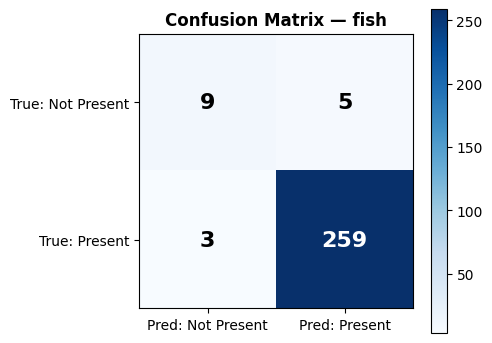


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Evaluation: DRONE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [drone — valid/ vs empty/]  (oversampled 8×)
    train :  624 present  +    82 not_present  =   706 total
    valid :   15 present  +    16 not_present  =    31 total
    test  :   10 present  +    10 not_present  =    20 total
  Overall Accuracy: 100.0%

              precision    recall  f1-score   support

 Not Present      1.000     1.000     1.000        10
     Present      1.000     1.000     1.000        10

    accuracy                          1.000        20
   macro avg      1.000     1.000     1.000        20
weighted avg      1.000     1.000     1.000        20



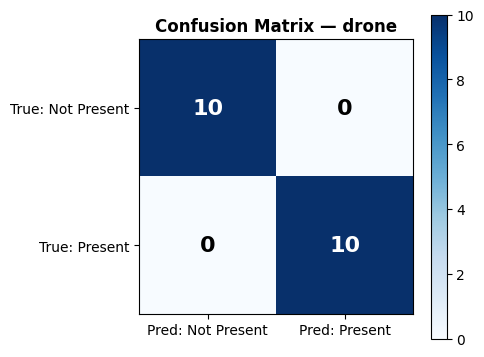

In [16]:
def evaluate_and_report(model, model_name):
    """Run evaluation on the held-out test split and print report + confusion matrix."""
    print(f"\n{'━'*50}")
    print(f" Evaluation: {model_name.upper()}")
    print(f"{'━'*50}")

    if model_name == "fish":
        _, _, test_samples = make_marine_splits()
    else:
        _, _, test_samples = make_drone_splits()

    ds     = PresenceDataset(test_samples, transform=val_transform, enhance=True)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    _, acc, y_true, y_pred = evaluate_model(model, loader)
    print(f"  Overall Accuracy: {acc:.1%}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=["Not Present", "Present"], digits=3))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: Not Present", "Pred: Present"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True: Not Present", "True: Present"])
    ax.set_title(f"Confusion Matrix — {model_name}", fontweight="bold")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f"confusion_{model_name}.jpg"), dpi=120, bbox_inches="tight")
    plt.show()


if fish_model and drone_model:
    evaluate_and_report(fish_model,  "fish")
    evaluate_and_report(drone_model, "drone")
else:
    print("Load both models first (Cell 11).")


## Cell 16 — 🔗 Drone Dataset Download Links

You currently have only 54 drone images. Here are verified sources to get more:

---

### ✅ Option 1 — Roboflow Universe (Easiest, free account)

| Dataset | Link | Images | Format |
|---|---|---|---|
| Underwater ROV/AUV Gate | https://universe.roboflow.com/auv-project/underwater-gate-sample | 1,025 | Download → Classification |
| Underwater Object Detection (has ROV class) | https://universe.roboflow.com/major-project-lfiet/underwater-object-detection-ozy81 | — | Filter ROV class |
| COU Dataset (ROV + AUV segmentation) | https://arxiv.org/pdf/2502.20651 | — | Paper with download link |

**How to download from Roboflow:**
1. Go to the link
2. Click **Download Dataset**
3. Choose format: **Folder** or **Classification**
4. Copy images into `dataset/underwater_drone/`

---

### ✅ Option 2 — YouTube frame extraction (fastest for deadline)

Search YouTube for: `underwater ROV footage` / `BlueROV2 underwater` / `AUV underwater drone`  
Use this code to extract frames from any video:

```python
import cv2
from pathlib import Path

video_path  = "rov_video.mp4"     # ← your downloaded video
output_dir  = Path("dataset/underwater_drone")
output_dir.mkdir(parents=True, exist_ok=True)

cap    = cv2.VideoCapture(video_path)
fps    = cap.get(cv2.CAP_PROP_FPS)
every  = int(fps * 2)             # extract 1 frame every 2 seconds
count  = 0
saved  = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if count % every == 0:
        cv2.imwrite(str(output_dir / f"drone_{saved:04d}.jpg"), frame)
        saved += 1
    count += 1

cap.release()
print(f"Extracted {saved} frames → {output_dir}")
```

---

### ✅ Option 3 — Kaggle datasets

```bash
pip install kaggle
# Place kaggle.json in ~/.kaggle/
kaggle datasets download -d akshatsng/underwater-dataset-for-8-classes-with-label
```

---

**Minimum recommended:** 200+ drone images for reliable training.  
With 54 images × 8× oversampling = 432 effective training samples — sufficient for a deadline demo.

## Cell 17 — Project Summary (for your report / presentation)

---

### System Overview

```
INPUT IMAGE
    │
    ▼
┌─────────────────────────────────────┐
│  IMAGE ENHANCEMENT                  │
│  • Gray World White Balance         │
│  • CLAHE (local contrast)           │
│  • Mild Unsharp Masking             │
└─────────────┬───────────────────────┘
              │
    ┌─────────┴──────────┐
    ▼                    ▼
┌──────────────┐  ┌──────────────────┐
│ EfficientNet │  │  EfficientNet    │
│    Model 1   │  │    Model 2       │
│ Marine Animal│  │ Underwater Drone │
│  (fish/coral)│  │  (ROV / AUV)     │
└──────┬───────┘  └───────┬──────────┘
       │ confidence        │ confidence
       ▼                   ▼
   ≥ threshold?        ≥ threshold?
       │ YES               │ YES
       ▼                   ▼
   Grad-CAM            Grad-CAM
   heatmap             heatmap
       │                   │
       ▼                   ▼
   Threshold           Threshold
   Binary mask         Binary mask
       │                   │
       ▼                   ▼
   Morphology          Morphology
   (close+open)        (close+open)
       │                   │
       ▼                   ▼
   Contours +          Contours +
   BBox + Label        BBox + Label
             │       │
             ▼       ▼
        FINAL OUTPUT IMAGE
```

### Key technical choices and why

| Choice | Reason |
|---|---|
| EfficientNet-B0 | 5.3M params, best accuracy/energy tradeoff, runs on Raspberry Pi |
| Two independent binary models | More flexible than one multi-class model; each can be updated independently |
| Gray World White Balance | Corrects the blue-green colour cast that confuses CNNs in underwater images |
| CLAHE | Improves local contrast without over-brightening or washing out detail |
| Grad-CAM | Localization for free — no bounding box labels needed for training |
| Morphological close+open | Fills holes in Grad-CAM masks and removes noise before contour extraction |
| 8× oversampling for drone | Compensates for small drone dataset (54 images) without collecting more data |